# Технологии ИИ ЛР №2: Генерация карты по спутниковому изображению - pix2pix
*Выполнил Владимир Недугов 6231-010402D*

Снимки со спутников применяются в различных областях дистанционного зондирования: сельское хозяйство, прогнозирование погодных условий, военная разведка и прочее. Одним из таких направлений является своевременная генерация схематических карт на основе изображений из космоса, что позволяет поддерживать карты городов и их окрестностей в актуальном состоянии.

## Постановка задачи 
На основе набора входных изображений, полученных со спутника, создается схематическое изображение карты с характерными способами отрисовки объектов (дороги, леса, здания и т.д.).

**Вход**: Изображение низкого разрешения в формате *.png*, *.bmp*, *.jpg*

**Выход**: Изображение карты в формате *.png*, *.bmp*, *.jpg*

## Пример набора данных
•	http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/

## Предлагаемые архитектуры
•	pix2pix (https://arxiv.org/abs/1611.07004)

---

## 1. Импорты и конфиги

In [1]:
! pip install -q "torch>=2.2" "torchvision>=0.17" "numpy>=1.24" "matplotlib>=3.7" "pandas>=2.0" "pillow>=9.5" "tqdm>=4.65"

In [2]:
import copy
import hashlib
import random
import tarfile
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as nn_functional
import torchvision
from PIL import Image, ImageOps
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets.utils import download_url
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as image_functional
from tqdm.auto import tqdm


@dataclass
class Config:
    seed: int = 42
    data_dir: str = "data"
    dataset_url: str = (
        "https://efrosgans.eecs.berkeley.edu/pix2pix/datasets/maps.tar.gz"
    )
    image_size: int = 256
    jitter_size: int = 286
    satellite_on_left: bool = True
    val_fraction: float = 0.15
    batch_size: int = 12
    num_workers: int = 0
    prefetch_factor: int = 4
    persistent_workers: bool = True
    use_amp: bool = True
    base_channels: int = 64
    constant_epochs: int = 100
    decay_epochs: int = 100
    learning_rate: float = 2e-4
    beta1: float = 0.5
    beta2: float = 0.999
    lambda_l1: float = 100.0
    paper_inference: bool = True
    preview_every: int = 10
    plot_every: int = 5
    run_training: bool = True


SMOKE_TEST = False
CFG = Config()
if SMOKE_TEST:
    CFG.constant_epochs = 1
    CFG.decay_epochs = 1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


print(f"PyTorch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"Device: {DEVICE}; smoke test: {SMOKE_TEST}")

PyTorch: 2.9.1+cu130
torchvision: 0.24.1+cu130
Device: cuda; smoke test: False


f:\ysda\ml1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. датасет

Используется [официальный архив maps](https://efrosgans.eecs.berkeley.edu/pix2pix/datasets/).
Каждый файл содержит два соответствующих RGB-изображения рядом:
слева спутниковый снимок, справа карта. Входом служит снимок,
целевой переменной - карта. Параметр `satellite_on_left` задаёт порядок
для собственного архива; проверьте его по визуализации ниже.

Из официальной папки `train` выделяется 15% для validation с фиксированным
seed. Папка `val` архива используется только как test (если есть `test`,
приоритет у неё). Полные дубликаты пар удаляются, чтобы они не пересекались
между train, validation и test.

In [3]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp"}

def image_paths(folder):
    """Return supported image files in a stable order."""
    return sorted(
        path for path in folder.glob("*")
        if path.suffix.lower() in IMAGE_SUFFIXES
    )

def extract_regular_files(archive_path, destination):
    """Extract regular files only, rejecting links and unsafe paths."""
    destination = destination.resolve()
    with tarfile.open(archive_path, "r:gz") as archive:
        for member in archive.getmembers():
            target = (destination / member.name).resolve()
            if not target.is_relative_to(destination):
                raise ValueError(f"Unsafe archive path: {member.name}")
            if member.isdir():
                target.mkdir(parents=True, exist_ok=True)
            elif member.isfile():
                target.parent.mkdir(parents=True, exist_ok=True)
                with archive.extractfile(member) as source:
                    with target.open("wb") as output:
                        while chunk := source.read(1024 * 1024):
                            output.write(chunk)
            else:
                raise ValueError(f"Unsupported archive entry: {member.name}")


def prepare_dataset(config):
    """Download maps once or reuse an existing local dataset."""
    data_dir = Path(config.data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)
    dataset_dir = data_dir / "maps"
    has_train = bool(image_paths(dataset_dir / "train"))
    has_test = bool(image_paths(dataset_dir / "test"))
    has_val = bool(image_paths(dataset_dir / "val"))
    if not (has_train and (has_test or has_val)):
        archive_path = data_dir / "maps.tar.gz"
        if not archive_path.exists():
            try:
                download_url(
                    config.dataset_url,
                    str(data_dir),
                    filename=archive_path.name,
                )
            except Exception as error:
                raise RuntimeError(
                    "Download failed. Place maps/train and maps/val "
                    "(or maps/test) inside data_dir and rerun this cell."
                ) from error
        extract_regular_files(archive_path, data_dir)
    if not image_paths(dataset_dir / "train"):
        raise FileNotFoundError("No training images in maps/train.")
    return dataset_dir


DATASET_DIR = prepare_dataset(CFG)

In [4]:
def pair_digest(path):
    """Hash decoded pixels to detect exact duplicate image pairs."""
    with Image.open(path) as image:
        image = image.convert("RGB")
        digest = hashlib.sha256()
        digest.update(str(image.size).encode("utf-8"))
        digest.update(image.tobytes())
    return digest.hexdigest()


def unique_pairs(paths, forbidden=None):
    """Keep the first occurrence of a pair unless its hash is forbidden."""
    seen = set() if forbidden is None else set(forbidden)
    retained = []
    hashes = []
    for path in paths:
        digest = pair_digest(path)
        if digest not in seen:
            seen.add(digest)
            retained.append(path)
            hashes.append(digest)
    return retained, hashes


official_train = image_paths(DATASET_DIR / "train")
test_folder = DATASET_DIR / "test"
if not image_paths(test_folder):
    test_folder = DATASET_DIR / "val"
official_test = image_paths(test_folder)
if not official_test:
    raise FileNotFoundError("No held-out images in maps/test or maps/val.")

test_paths, test_hashes = unique_pairs(official_test)
pool_paths, pool_hashes = unique_pairs(official_train, test_hashes)
if len(pool_paths) < 2:
    raise ValueError("At least two distinct training pairs are required.")

rng = np.random.default_rng(CFG.seed)
indices = rng.permutation(len(pool_paths))
val_size = max(1, round(len(pool_paths) * CFG.val_fraction))
val_size = min(val_size, len(pool_paths) - 1)
val_indices = indices[:val_size]
train_indices = indices[val_size:]
val_paths = [pool_paths[index] for index in val_indices]
train_paths = [pool_paths[index] for index in train_indices]
train_hashes = {pool_hashes[index] for index in train_indices}
val_hashes = {pool_hashes[index] for index in val_indices}

if SMOKE_TEST:
    train_paths = train_paths[:8]
    val_paths = val_paths[:4]
    test_paths = test_paths[:4]

print(f"Train: {len(train_paths)}")
print(f"Validation: {len(val_paths)}")
print(f"Test: {len(test_paths)} (official {test_folder.name})")
print(
    "Removed duplicates:",
    len(official_train) + len(official_test) - len(pool_paths) - len(test_hashes),
)

Train: 932
Validation: 164
Test: 1098 (official val)
Removed duplicates: 0


*Аугментации*

Для train применяются одинаковые к обеим половинам resize до 286x286,
случайный crop до 256x256 и горизонтальное отражение. 

Для validation, test и собственного снимка - только resize до 256x256. RGB переводится
в диапазон [-1, 1], соответствующий выходу `Tanh` генератора.

In [5]:
def split_pair(path, satellite_on_left=True):
    """Read a side-by-side pair and return satellite image, map."""
    with Image.open(path) as source:
        pair = source.convert("RGB")
    width, height = pair.size
    if width % 2:
        raise ValueError(f"Pair width must be even: {path}")
    half = width // 2
    left = pair.crop((0, 0, half, height))
    right = pair.crop((half, 0, width, height))
    return (left, right) if satellite_on_left else (right, left)


def normalize_image(image):
    """Convert an RGB PIL image to a CHW tensor in [-1, 1]."""
    tensor = image_functional.to_tensor(image)
    return image_functional.normalize(tensor, [0.5] * 3, [0.5] * 3)


class MapsDataset(Dataset):
    """Aligned satellite-to-map pairs with synchronized augmentation."""

    def __init__(self, paths, config, training=False):
        self.paths = list(paths)
        self.config = config
        self.training = training

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        satellite, target = split_pair(
            self.paths[index], self.config.satellite_on_left
        )
        size = (
            self.config.jitter_size
            if self.training else self.config.image_size
        )
        satellite = image_functional.resize(
            satellite, [size, size], InterpolationMode.BICUBIC
        )
        target = image_functional.resize(
            target, [size, size], InterpolationMode.BICUBIC
        )
        if self.training:
            crop = transforms.RandomCrop.get_params(
                satellite,
                output_size=(
                    self.config.image_size, self.config.image_size
                ),
            )
            satellite = image_functional.crop(satellite, *crop)
            target = image_functional.crop(target, *crop)
            if torch.rand(()).item() < 0.5:
                satellite = image_functional.hflip(satellite)
                target = image_functional.hflip(target)
        return normalize_image(satellite), normalize_image(target)


def seed_worker(worker_id):
    """Initialize NumPy and Python RNGs in a data-loader worker."""
    worker_seed = torch.initial_seed() % (2 ** 32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)


train_dataset = MapsDataset(train_paths, CFG, training=True)
val_dataset = MapsDataset(val_paths, CFG)
test_dataset = MapsDataset(test_paths, CFG)
loader_rng = torch.Generator().manual_seed(CFG.seed)
loader_options = {
    "batch_size": CFG.batch_size,
    "num_workers": CFG.num_workers,
    "pin_memory": DEVICE.type == "cuda",
    "worker_init_fn": seed_worker,
}
if CFG.num_workers > 0:
    loader_options.update({
        "prefetch_factor": CFG.prefetch_factor,
        "persistent_workers": CFG.persistent_workers,
    })
train_loader = DataLoader(
    train_dataset, shuffle=True, generator=loader_rng, **loader_options
)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)


def to_unit_interval(tensor):
    """Convert normalized images to the [0, 1] display/metric range."""
    return ((tensor.detach().float() + 1.0) / 2.0).clamp(0.0, 1.0)


def show_triplets(inputs, targets, predictions=None, max_items=3):
    """Display input, generated map (if supplied), and reference map."""
    count = min(max_items, len(inputs))
    batches = [inputs, targets]
    titles = ["Спутниковый снимок", "Эталонная карта"]
    if predictions is not None:
        batches = [inputs, predictions, targets]
        titles = ["Спутниковый снимок", "pix2pix", "Эталонная карта"]
    figure, axes = plt.subplots(
        count, len(batches), figsize=(4 * len(batches), 4 * count),
        squeeze=False,
    )
    for row in range(count):
        for column, (batch, title) in enumerate(zip(batches, titles)):
            image = to_unit_interval(batch[row]).cpu().permute(1, 2, 0)
            axes[row, column].imshow(image)
            axes[row, column].set_title(title)
            axes[row, column].axis("off")
    figure.tight_layout()
    plt.show()
    plt.close(figure)

### Примеры данных из датасета

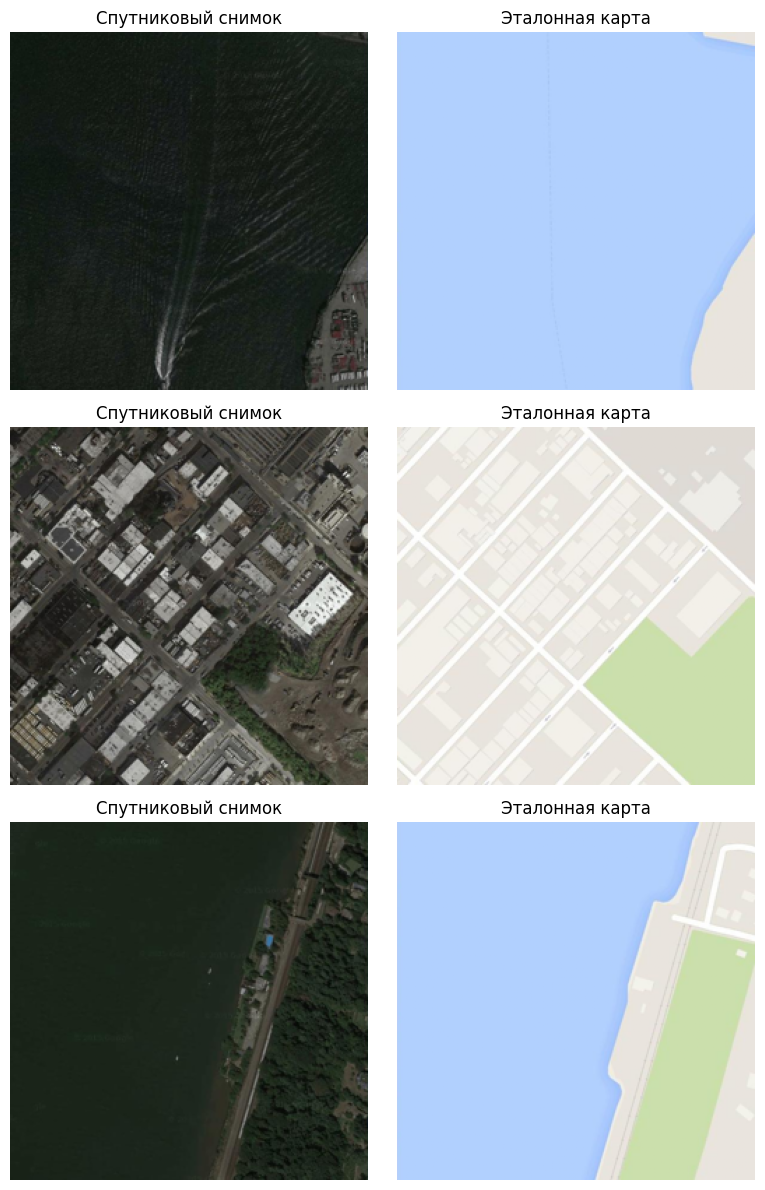

In [6]:
preview_pairs = [val_dataset[index] for index in range(min(3, len(val_dataset)))]
preview_inputs = torch.stack([pair[0] for pair in preview_pairs])
preview_targets = torch.stack([pair[1] for pair in preview_pairs])
show_triplets(preview_inputs, preview_targets)

## 3. Архитектура pix2pix

Основа - Isola et al., *Image-to-Image Translation with Conditional Adversarial Networks* (CVPR 2017)

In [7]:
class DownBlock(nn.Module):
    """One encoder level: activation, convolution, optional BatchNorm."""

    def __init__(self, in_channels, out_channels, normalize=True,
                 activate=True):
        super().__init__()
        layers = []
        if activate:
            layers.append(nn.LeakyReLU(0.2, inplace=False))
        layers.append(nn.Conv2d(
            in_channels, out_channels, 4, 2, 1, bias=not normalize
        ))
        if normalize:
            layers.append(nn.BatchNorm2d(
                out_channels, track_running_stats=False
            ))
        self.block = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.block(inputs)


class UpBlock(nn.Module):
    """One decoder level followed by an encoder skip connection."""

    def __init__(self, in_channels, out_channels, dropout=False):
        super().__init__()
        layers = [
            nn.ReLU(inplace=False),
            nn.ConvTranspose2d(
                in_channels, out_channels, 4, 2, 1, bias=False
            ),
            nn.BatchNorm2d(out_channels, track_running_stats=False),
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.block = nn.Sequential(*layers)

    def forward(self, inputs, skip):
        return torch.cat([self.block(inputs), skip], dim=1)


class UNetGenerator(nn.Module):
    """Eight-level pix2pix U-Net for 256 x 256 RGB image pairs."""

    def __init__(self, base_channels=64):
        super().__init__()
        channels = [
            base_channels * scale for scale in [1, 2, 4, 8, 8, 8, 8, 8]
        ]
        self.down_blocks = nn.ModuleList()
        in_channels = 3
        for index, out_channels in enumerate(channels):
            self.down_blocks.append(DownBlock(
                in_channels, out_channels,
                normalize=index not in {0, 7},
                activate=index != 0,
            ))
            in_channels = out_channels
        self.up_blocks = nn.ModuleList()
        for index, out_channels in enumerate(reversed(channels[:-1])):
            self.up_blocks.append(UpBlock(
                in_channels, out_channels, dropout=index < 3
            ))
            in_channels = 2 * out_channels
        self.output = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.ConvTranspose2d(in_channels, 3, 4, 2, 1),
            nn.Tanh(),
        )

    def forward(self, inputs):
        skips = []
        hidden = inputs
        for block in self.down_blocks:
            hidden = block(hidden)
            skips.append(hidden)
        for block, skip in zip(self.up_blocks, reversed(skips[:-1])):
            hidden = block(hidden, skip)
        return self.output(hidden)


class PatchDiscriminator(nn.Module):
    """Conditional PatchGAN with a 70 x 70 receptive field."""

    def __init__(self, base_channels=64):
        super().__init__()
        layers = [
            nn.Conv2d(6, base_channels, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=False),
        ]
        in_channels = base_channels
        for scale, stride in [(2, 2), (4, 2), (8, 1)]:
            out_channels = base_channels * scale
            layers.extend([
                nn.Conv2d(
                    in_channels, out_channels, 4, stride, 1, bias=False
                ),
                nn.BatchNorm2d(out_channels),
                nn.LeakyReLU(0.2, inplace=False),
            ])
            in_channels = out_channels
        layers.append(nn.Conv2d(in_channels, 1, 4, 1, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs, targets):
        return self.network(torch.cat([inputs, targets], dim=1))


def initialize_weights(module):
    """Apply the Gaussian initialization used by pix2pix."""
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(module.weight, 0.0, 0.02)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.BatchNorm2d):
        nn.init.normal_(module.weight, 1.0, 0.02)
        nn.init.zeros_(module.bias)


generator = UNetGenerator(CFG.base_channels).to(DEVICE)
discriminator = PatchDiscriminator(CFG.base_channels).to(DEVICE)
generator.apply(initialize_weights)
discriminator.apply(initialize_weights)
print("Generator parameters:", sum(p.numel() for p in generator.parameters()))
print("Discriminator parameters:",
      sum(p.numel() for p in discriminator.parameters()))

with torch.no_grad():
    example = torch.zeros(1, 3, 256, 256, device=DEVICE)
    generated = generator(example)
    logits = discriminator(example, generated)
assert generated.shape == (1, 3, 256, 256)
assert logits.shape == (1, 1, 30, 30)
print("G output:", tuple(generated.shape))
print("D output:", tuple(logits.shape))
del example, generated, logits

generator.apply(initialize_weights)
discriminator.apply(initialize_weights)
for module in discriminator.modules():
    if isinstance(module, nn.BatchNorm2d):
        module.reset_running_stats()

Generator parameters: 54414531
Discriminator parameters: 2768705
G output: (1, 3, 256, 256)
D output: (1, 1, 30, 30)


## 4. Метрики

In [8]:
@torch.no_grad()
def image_quality(predictions, targets):
    """Return per-image MAE, PSNR and Gaussian-window RGB SSIM."""
    dimensions = (1, 2, 3)
    paper_l1 = (predictions.float() - targets.float()).abs().mean(dim=dimensions)
    predictions = to_unit_interval(predictions)
    targets = to_unit_interval(targets)
    mae = (predictions - targets).abs().mean(dim=dimensions)
    mse = (predictions - targets).square().mean(dim=dimensions)
    psnr = -10.0 * torch.log10(mse.clamp_min(1e-12))

    coordinates = torch.arange(11, dtype=predictions.dtype, device=predictions.device) - 5
    gaussian = torch.exp(-coordinates.square() / (2.0 * 1.5 ** 2))
    gaussian = gaussian / gaussian.sum()
    window = (gaussian[:, None] * gaussian[None, :])[None, None]
    channels = predictions.shape[1]
    window = window.expand(channels, 1, 11, 11).contiguous()

    def average(images):
        return nn_functional.conv2d(images, window, groups=channels)

    mean_x = average(predictions)
    mean_y = average(targets)
    variance_x = average(predictions.square()) - mean_x.square()
    variance_y = average(targets.square()) - mean_y.square()
    covariance = average(predictions * targets) - mean_x * mean_y
    c1, c2 = 0.01 ** 2, 0.03 ** 2
    numerator = (2 * mean_x * mean_y + c1) * (2 * covariance + c2)
    denominator = (
        (mean_x.square() + mean_y.square() + c1)
        * (variance_x + variance_y + c2)
    )
    ssim = (numerator / denominator).mean(dim=dimensions)
    return {"paper_l1": paper_l1, "mae": mae, "psnr": psnr, "ssim": ssim}


def evaluation_rng_devices():
    """Select the CUDA RNG, if any, that must be isolated during evaluation."""
    if DEVICE.type == "cuda":
        return [DEVICE.index or torch.cuda.current_device()]
    return []


@torch.no_grad()
def evaluate(model, loader, config):
    """Evaluate all samples without changing training RNG or model mode."""
    previous_mode = model.training
    totals = {"paper_l1": 0.0, "mae": 0.0, "psnr": 0.0, "ssim": 0.0}
    count = 0
    try:
        model.train(config.paper_inference)
        with torch.random.fork_rng(devices=evaluation_rng_devices()):
            torch.manual_seed(config.seed)
            for inputs, targets in loader:
                inputs = inputs.to(DEVICE, non_blocking=True)
                targets = targets.to(DEVICE, non_blocking=True)
                predictions = model(inputs)
                quality = image_quality(predictions, targets)
                for name, values in quality.items():
                    totals[name] += values.sum().item()
                count += len(inputs)
    finally:
        model.train(previous_mode)
    if count == 0:
        raise ValueError("Cannot evaluate an empty dataset.")
    return {name: total / count for name, total in totals.items()}

## 5. Обучение

В каждом шаге сначала обновляется D, затем G. 

Learning rate задаётся стандартными scheduler-ами PyTorch: 
- первые 100 эпох он постоянный, 
- затем 100 эпох линейно уменьшается через `PolynomialLR(power=1.0)` внутри `SequentialLR`.

In [9]:
gan_loss = nn.BCEWithLogitsLoss()
l1_loss = nn.L1Loss()
optimizer_g = torch.optim.Adam(
    generator.parameters(), lr=CFG.learning_rate,
    betas=(CFG.beta1, CFG.beta2),
)
optimizer_d = torch.optim.Adam(
    discriminator.parameters(), lr=CFG.learning_rate,
    betas=(CFG.beta1, CFG.beta2),
)
amp_enabled = CFG.use_amp and DEVICE.type == "cuda"
scaler = torch.amp.GradScaler(enabled=amp_enabled)


def make_scheduler(optimizer):
    """100 constant epochs, then linear decay using only torch schedulers."""
    if CFG.decay_epochs == 0:
        return torch.optim.lr_scheduler.ConstantLR(
            optimizer, factor=1.0, total_iters=CFG.constant_epochs
        )
    constant = torch.optim.lr_scheduler.ConstantLR(
        optimizer, factor=1.0, total_iters=CFG.constant_epochs
    )
    linear_decay = torch.optim.lr_scheduler.PolynomialLR(
        optimizer, total_iters=CFG.decay_epochs, power=1.0
    )
    return torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[constant, linear_decay],
        milestones=[CFG.constant_epochs],
    )


scheduler_g = make_scheduler(optimizer_g)
scheduler_d = make_scheduler(optimizer_d)


def autocast_context():
    return torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=amp_enabled,
    )


def train_one_epoch(model_g, model_d, loader):
    """Alternate discriminator and generator updates for one full epoch."""
    model_g.train()
    model_d.train()
    totals = {
        "g_loss": 0.0, "g_gan": 0.0, "g_l1": 0.0, "d_loss": 0.0,
        "d_real_prob": 0.0, "d_fake_prob": 0.0, "d_accuracy": 0.0,
        "paper_l1": 0.0, "mae": 0.0, "psnr": 0.0, "ssim": 0.0,
    }
    count = 0
    progress = tqdm(loader, desc="Train", leave=False)
    for inputs, targets in progress:
        inputs = inputs.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        model_d.requires_grad_(True)
        optimizer_d.zero_grad(set_to_none=True)
        with autocast_context():
            predictions = model_g(inputs)
            real_logits = model_d(inputs, targets)
            fake_logits_detached = model_d(inputs, predictions.detach())
            loss_d = 0.5 * (
                gan_loss(real_logits, torch.ones_like(real_logits))
                + gan_loss(fake_logits_detached, torch.zeros_like(fake_logits_detached))
            )
        scaler.scale(loss_d).backward()
        scaler.step(optimizer_d)

        model_d.requires_grad_(False)
        optimizer_g.zero_grad(set_to_none=True)
        with autocast_context():
            fake_logits = model_d(inputs, predictions)
            loss_g_gan = gan_loss(fake_logits, torch.ones_like(fake_logits))
            loss_g_l1 = l1_loss(predictions, targets)
            loss_g = loss_g_gan + CFG.lambda_l1 * loss_g_l1
        scaler.scale(loss_g).backward()
        scaler.step(optimizer_g)
        scaler.update()
        model_d.requires_grad_(True)

        batch_size = len(inputs)
        losses = {
            "g_loss": loss_g.item(), "g_gan": loss_g_gan.item(),
            "g_l1": loss_g_l1.item(), "d_loss": loss_d.item(),
        }
        for name, value in losses.items():
            totals[name] += value * batch_size

        with torch.no_grad():
            real_prob = torch.sigmoid(real_logits.float()).mean().item()
            fake_prob = torch.sigmoid(fake_logits_detached.float()).mean().item()
            real_correct = (real_logits > 0).float().mean().item()
            fake_correct = (fake_logits_detached < 0).float().mean().item()
            totals["d_real_prob"] += real_prob * batch_size
            totals["d_fake_prob"] += fake_prob * batch_size
            totals["d_accuracy"] += 0.5 * (real_correct + fake_correct) * batch_size
            quality = image_quality(predictions, targets)
            for name, values in quality.items():
                totals[name] += values.sum().item()

        count += batch_size
        progress.set_postfix({
            "G": f"{totals['g_loss'] / count:.3f}",
            "D": f"{totals['d_loss'] / count:.3f}",
            "L1": f"{totals['paper_l1'] / count:.4f}",
            "Dacc": f"{totals['d_accuracy'] / count:.3f}",
            "PSNR": f"{totals['psnr'] / count:.2f}",
            "SSIM": f"{totals['ssim'] / count:.4f}",
        })
    return {name: value / count for name, value in totals.items()}


@torch.no_grad()
def predict_batch(model, inputs, config):
    """Generate maps using the same protocol and seed as evaluation."""
    previous_mode = model.training
    try:
        model.train(config.paper_inference)
        with torch.random.fork_rng(devices=evaluation_rng_devices()):
            torch.manual_seed(config.seed)
            with autocast_context():
                predictions = model(inputs.to(DEVICE)).float().cpu()
    finally:
        model.train(previous_mode)
    return predictions


def plot_training_history(rows):
    """Display training curves with matplotlib without saving files."""
    if not rows:
        return
    frame = pd.DataFrame(rows)
    figure, axes = plt.subplots(3, 2, figsize=(13, 12))

    axes[0, 0].plot(frame["epoch"], frame["train_g_loss"], label="G total")
    axes[0, 0].plot(frame["epoch"], frame["train_g_gan"], label="G GAN")
    axes[0, 0].plot(frame["epoch"], frame["train_d_loss"], label="D")
    axes[0, 0].set_title("GAN losses")

    axes[0, 1].plot(frame["epoch"], frame["train_d_accuracy"], label="D accuracy")
    axes[0, 1].plot(frame["epoch"], frame["train_d_real_prob"], label="D(real)")
    axes[0, 1].plot(frame["epoch"], frame["train_d_fake_prob"], label="D(fake)")
    axes[0, 1].set_title("Discriminator diagnostics")

    for axis, metric, title in [
        (axes[1, 0], "paper_l1", "Paper L1"),
        (axes[1, 1], "mae", "MAE"),
        (axes[2, 0], "psnr", "PSNR"),
        (axes[2, 1], "ssim", "SSIM"),
    ]:
        axis.plot(frame["epoch"], frame[f"train_{metric}"], label="train")
        axis.plot(frame["epoch"], frame[f"val_{metric}"], label="validation")
        axis.set_title(title)

    for axis in axes.flat:
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.3)
        axis.legend()
    figure.tight_layout()
    plt.show()
    plt.close(figure)

In [10]:
from IPython.display import clear_output

Epoch 200/200 | lr=0.000002
G=9.5316 | D=0.0645
train L1=0.0613, MAE=0.0307, PSNR=26.43, SSIM=0.6929
val L1=0.0670, MAE=0.0335, PSNR=25.88, SSIM=0.6903
Best epoch=185, best val L1=0.0664


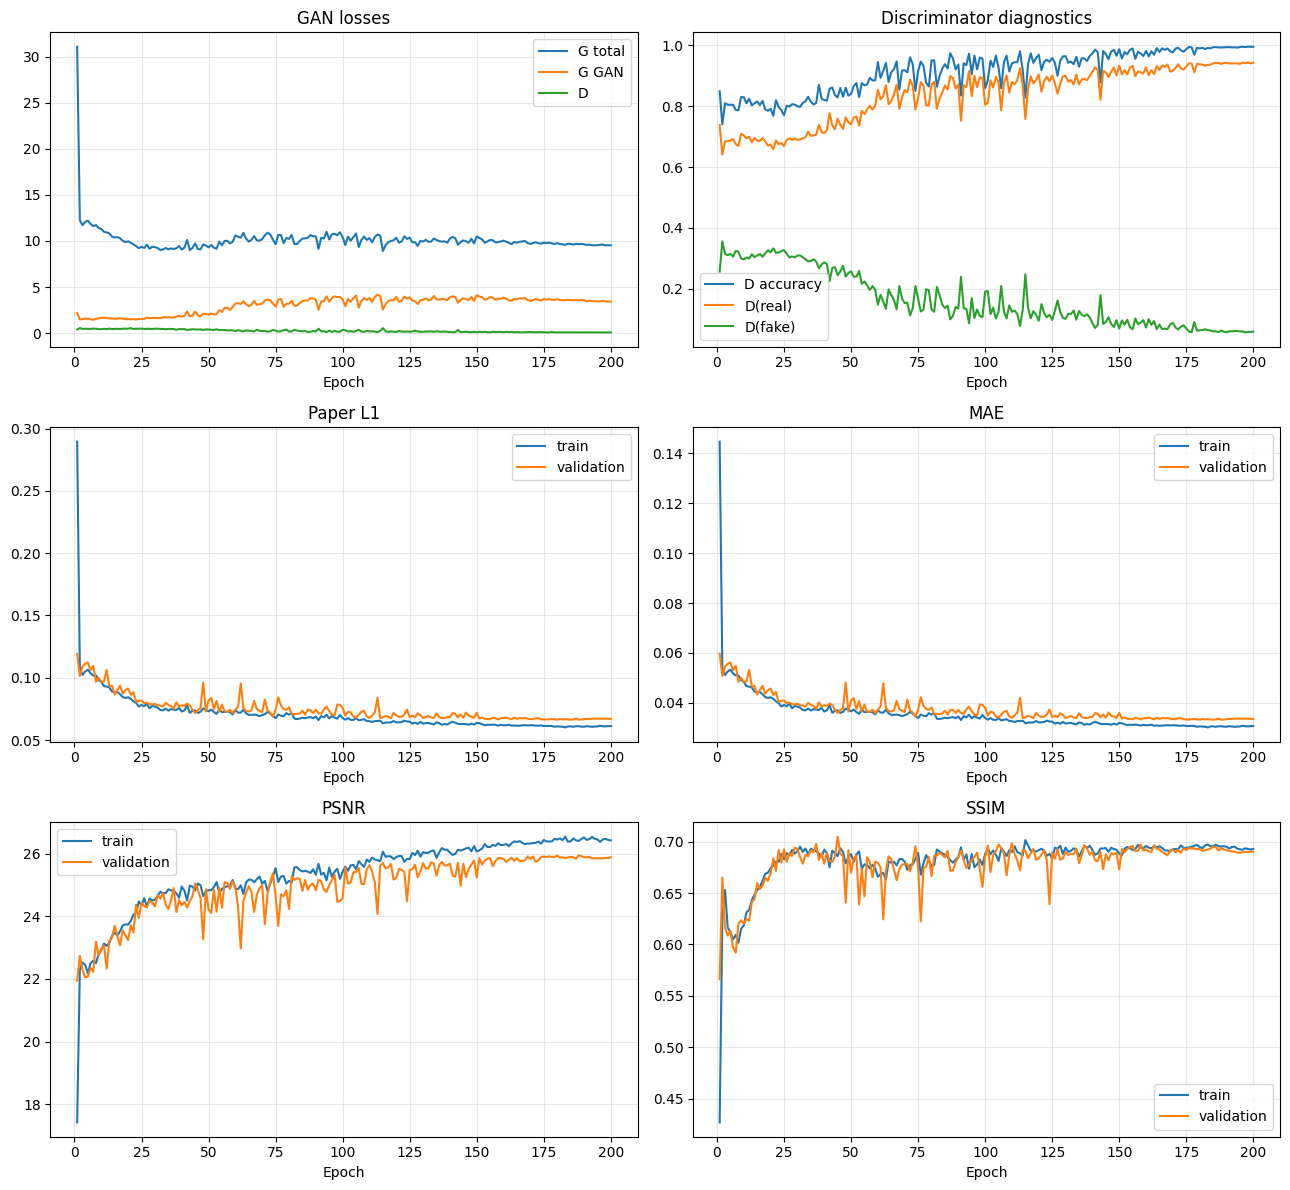

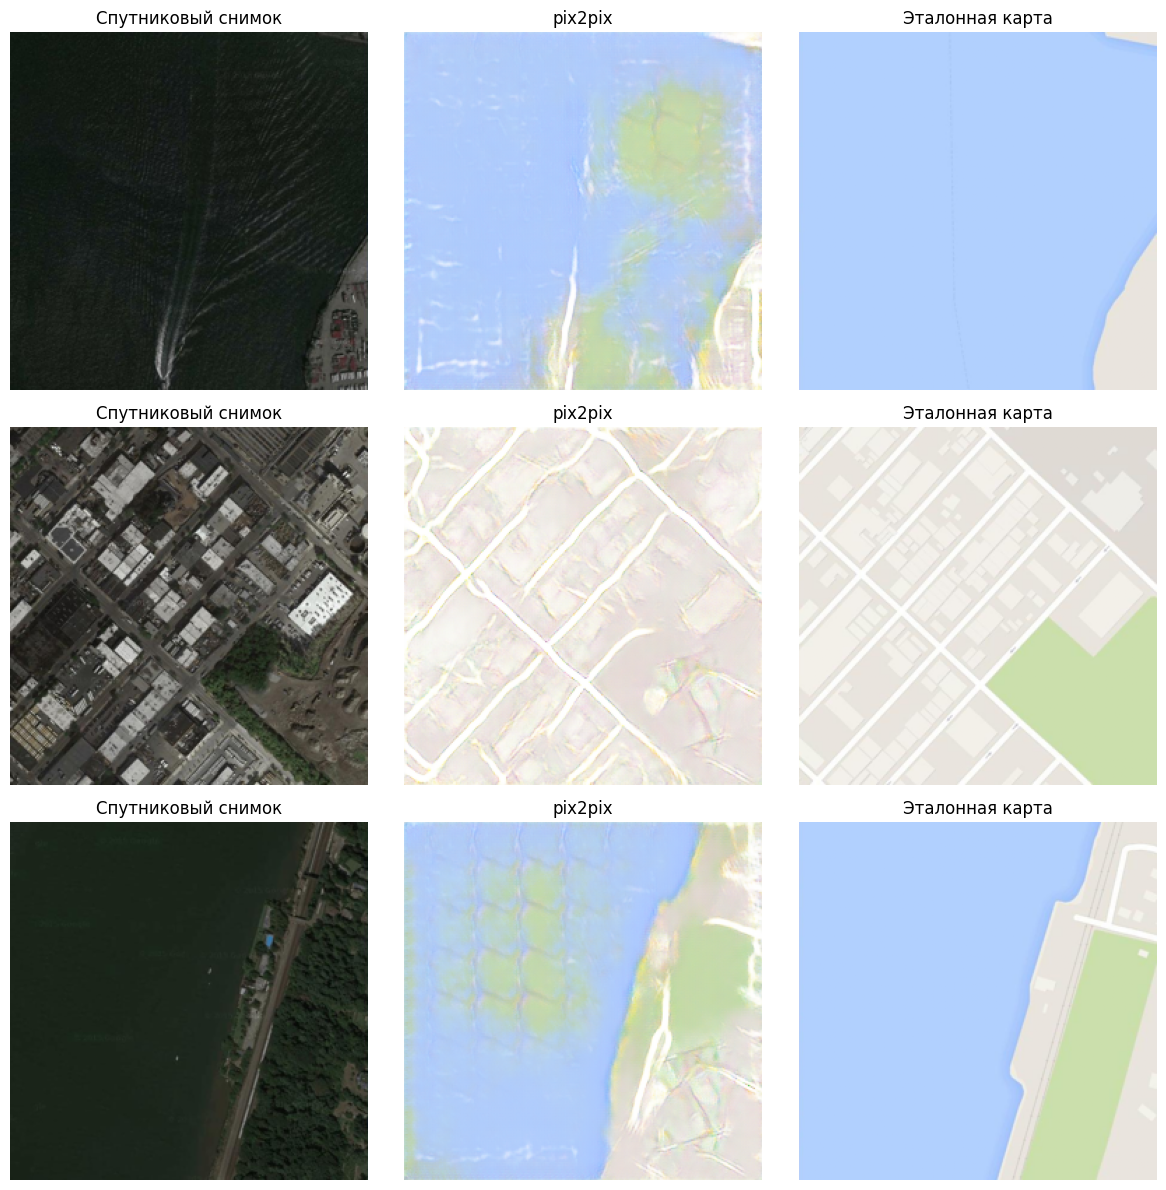

In [11]:
history = []
best_val_l1 = float("inf")
best_epoch = None
best_val_metrics = None
best_generator_state = None
total_epochs = CFG.constant_epochs + CFG.decay_epochs

if CFG.run_training:
    for epoch in range(1, total_epochs + 1):
        current_lr = optimizer_g.param_groups[0]["lr"]
        train_scores = train_one_epoch(generator, discriminator, train_loader)
        val_scores = evaluate(generator, val_loader, CFG)

        row = {"epoch": epoch, "lr": current_lr}
        row.update({f"train_{key}": value for key, value in train_scores.items()})
        row.update({f"val_{key}": value for key, value in val_scores.items()})
        history.append(row)

        if val_scores["paper_l1"] < best_val_l1:
            best_val_l1 = val_scores["paper_l1"]
            best_epoch = epoch
            best_val_metrics = dict(val_scores)
            best_generator_state = copy.deepcopy(generator.state_dict())

        scheduler_g.step()
        scheduler_d.step()

        need_plot = (
            epoch == 1
            or epoch % CFG.plot_every == 0
            or epoch == total_epochs
        )

        need_preview = (
            epoch == 1
            or epoch % CFG.preview_every == 0
            or epoch == total_epochs
        )

        if need_plot or need_preview:
            clear_output(wait=True)

            print(
                f"Epoch {epoch:03d}/{total_epochs} | "
                f"lr={current_lr:.6f}\n"
                f"G={train_scores['g_loss']:.4f} | "
                f"D={train_scores['d_loss']:.4f}\n"
                f"train L1={train_scores['paper_l1']:.4f}, "
                f"MAE={train_scores['mae']:.4f}, "
                f"PSNR={train_scores['psnr']:.2f}, "
                f"SSIM={train_scores['ssim']:.4f}\n"
                f"val L1={val_scores['paper_l1']:.4f}, "
                f"MAE={val_scores['mae']:.4f}, "
                f"PSNR={val_scores['psnr']:.2f}, "
                f"SSIM={val_scores['ssim']:.4f}\n"
                f"Best epoch={best_epoch}, "
                f"best val L1={best_val_l1:.4f}"
            )

            if need_plot:
                plot_training_history(history)

            if need_preview:
                predictions = predict_batch(
                    generator,
                    preview_inputs,
                    CFG
                )

                show_triplets(
                    preview_inputs,
                    preview_targets,
                    predictions
                )

    if best_generator_state is not None:
        generator.load_state_dict(best_generator_state)
        del best_generator_state
else:
    print("Training skipped.")

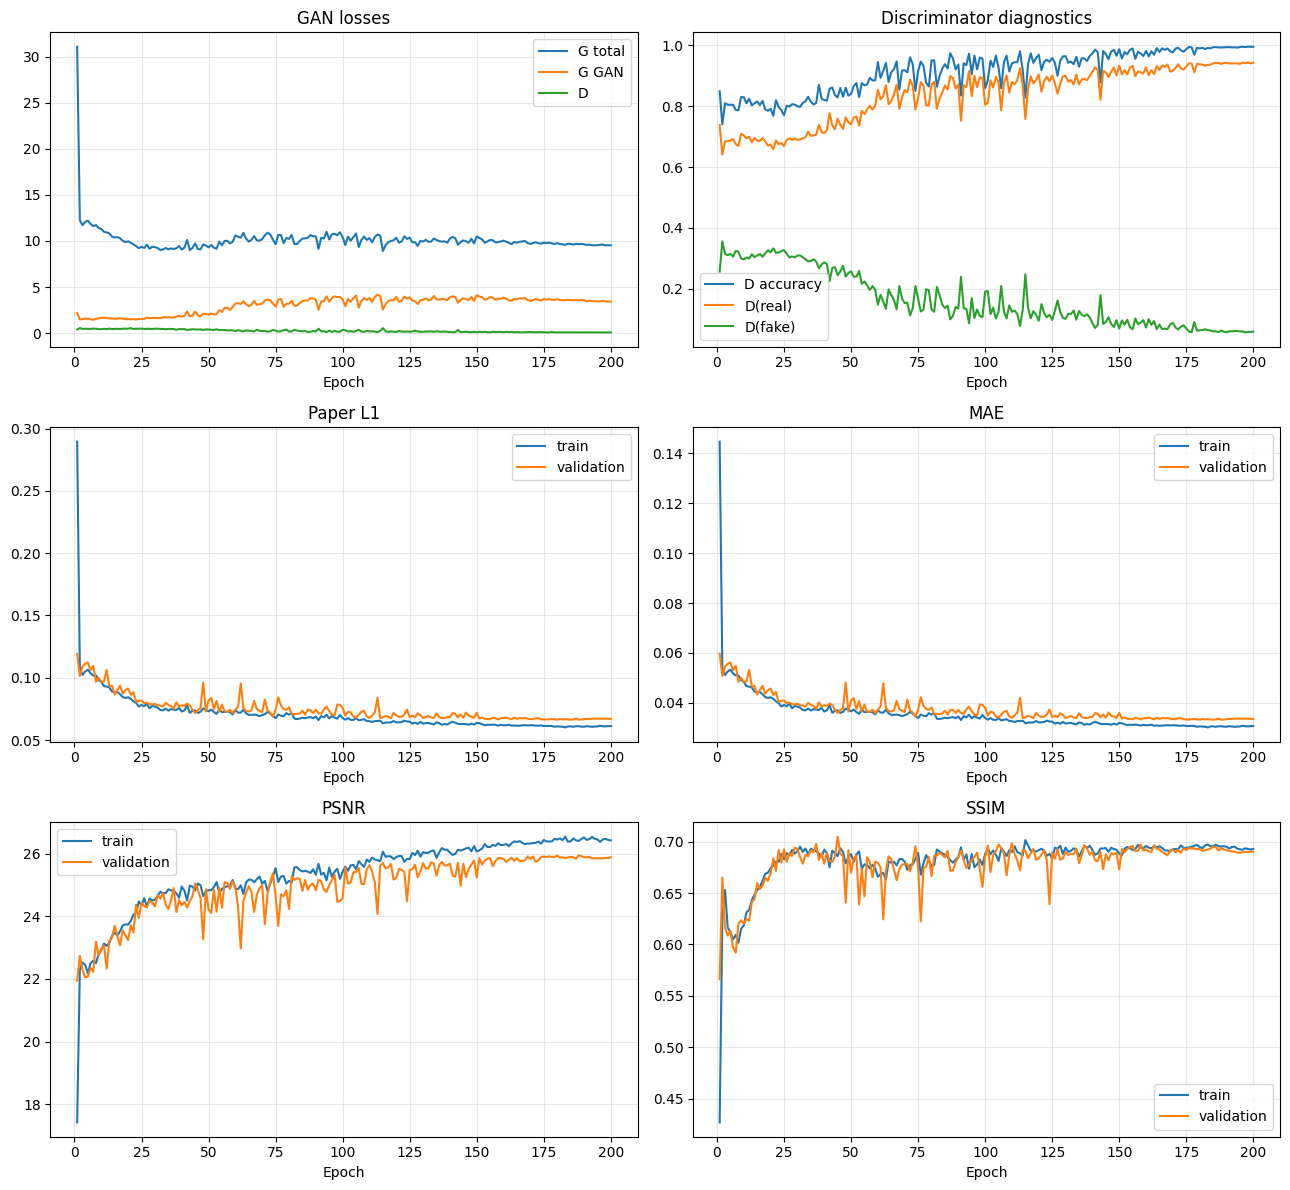

,epoch,lr,train_g_loss,train_g_gan,train_g_l1,train_d_loss,train_d_real_prob,train_d_fake_prob,train_d_accuracy,train_paper_l1,train_mae,train_psnr,train_ssim,val_paper_l1,val_mae,val_psnr,val_ssim
195,196,0.000010,9.602768,3.446504,0.061563,0.064388,0.943800,0.059397,0.995644,0.061563,0.030781,26.376952,0.692184,0.067286,0.033643,25.859166,0.689705
196,197,0.000008,9.609285,3.496466,0.061128,0.064032,0.941931,0.055872,0.994489,0.061128,0.030564,26.456186,0.693473,0.067211,0.033605,25.849776,0.690157
197,198,0.000006,9.522593,3.419574,0.061030,0.063010,0.943946,0.057644,0.996097,0.061030,0.030515,26.472092,0.692855,0.067188,0.033594,25.865380,0.689920
198,199,0.000004,9.549138,3.422717,0.061264,0.065226,0.941172,0.057807,0.995402,0.061264,0.030632,26.441198,0.692314,0.067157,0.033578,25.864149,0.690073
199,200,0.000002,9.531604,3.400310,0.061313,0.064511,0.943052,0.058560,0.995378,0.061313,0.030656,26.425797,0.692896,0.067045,0.033523,25.882766,0.690313


In [12]:
if history:
    history_frame = pd.DataFrame(history)
    plot_training_history(history)
    display(history_frame.tail())
else:
    print("No training history yet.")

## 6. Финальный инференс на test

In [13]:
if CFG.run_training and best_epoch is None:
    raise RuntimeError("Training did not produce a best model state.")

inference_model = generator
inference_model.requires_grad_(False)
test_scores = evaluate(inference_model, test_loader, CFG)

print(f"Best epoch: {best_epoch}")
print("Validation:", best_val_metrics)
print("Test:", test_scores)
display(pd.DataFrame([test_scores], index=["test"]))

Best epoch: 185
Validation: {'paper_l1': 0.06635392148320268, 'mae': 0.03317696074160134, 'psnr': 25.897782674649868, 'ssim': 0.6950334455908799}
Test: {'paper_l1': 0.07127331522970251, 'mae': 0.03563665769627837, 'psnr': 25.236609537093365, 'ssim': 0.6670587449343044}


,paper_l1,mae,psnr,ssim
test,0.071273,0.035637,25.23661,0.667059


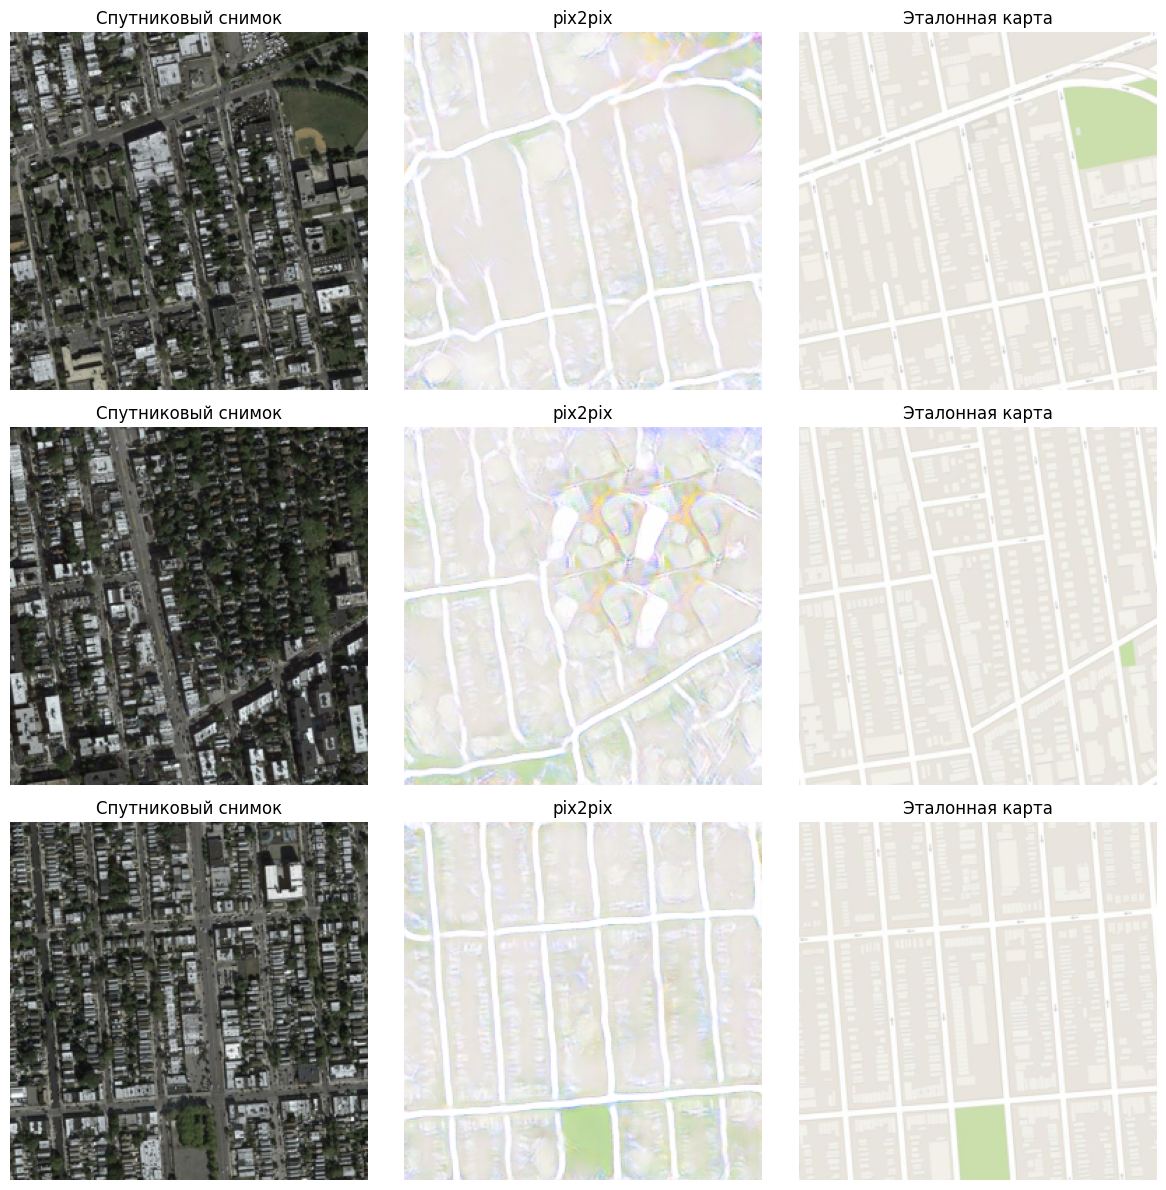

In [14]:
test_examples = [
    test_dataset[index] for index in range(min(3, len(test_dataset)))
]
test_inputs = torch.stack([pair[0] for pair in test_examples])
test_targets = torch.stack([pair[1] for pair in test_examples])
test_predictions = predict_batch(inference_model, test_inputs, CFG)
show_triplets(test_inputs, test_targets, test_predictions)

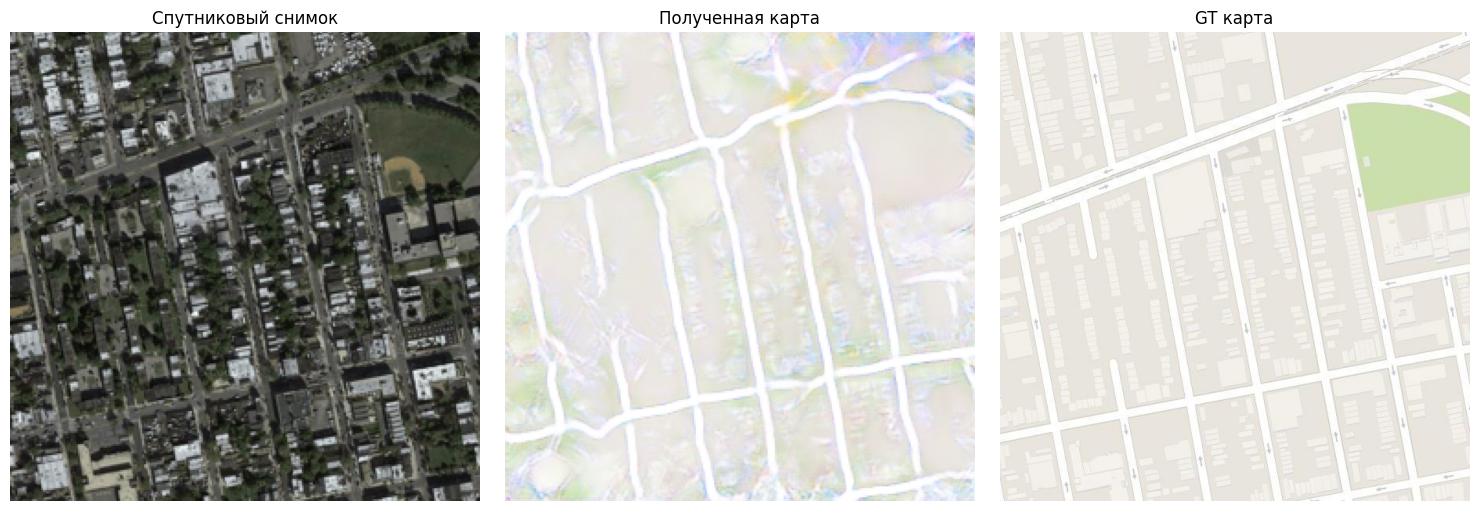

In [15]:
@torch.no_grad()
def infer_pil_image(model, image, config):
    """Generate a map from a PIL satellite image without saving files."""
    satellite = ImageOps.exif_transpose(image).convert("RGB")
    satellite = image_functional.resize(
        satellite,
        [config.image_size, config.image_size],
        InterpolationMode.BICUBIC,
    )
    inputs = normalize_image(satellite).unsqueeze(0)
    prediction = predict_batch(model, inputs, config)[0]
    generated = image_functional.to_pil_image(to_unit_interval(prediction))
    return satellite, generated


sample_satellite, sample_gt = split_pair(
    test_paths[0], CFG.satellite_on_left
)
input_image, output_image = infer_pil_image(
    inference_model, sample_satellite, CFG
)

figure, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, image, title in zip(
    axes,
    [input_image, output_image, sample_gt],
    ["Спутниковый снимок", "Полученная карта", "GT карта"],
):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")
figure.tight_layout()
plt.show()
plt.close(figure)